In [5]:
import sys
!{sys.executable} -m pip install ants --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys
!{sys.executable} -m pip install scipy --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install antspyx --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Cell 1 — Load artifacts
import numpy as np, nibabel as nib, ants, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

INPUT_IMAGE = "image/I193095.nii.gz"

template   = np.load("_pp_template.npy")
mask       = np.load("_pp_mask.npy").astype(bool)
cereb_mask = np.load("_pp_cereb.npy").astype(bool)

mni = ants.image_read(ants.get_ants_data("mni"))

print(f"Template:   {template.shape}")
print(f"Brain mask: {mask.sum()} voxels")
print(f"Cereb mask: {cereb_mask.sum()} voxels")

Template:   (182, 218, 182)
Brain mask: 1840910 voxels
Cereb mask: 195313 voxels


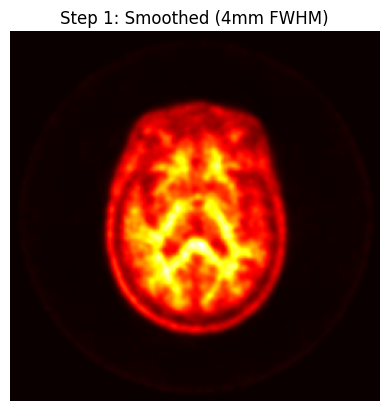

Smoothed shape: (256, 256, 207)  voxel size: (1.21875, 1.21875, 1.21875)


In [11]:
img = nib.load(INPUT_IMAGE)
vox = img.header.get_zooms()[:3]
sigma = [(4.0 / 2.355) / s for s in vox]

smoothed = gaussian_filter(img.get_fdata().astype(np.float32), sigma)

z = smoothed.shape[2] // 2
plt.imshow(np.rot90(smoothed[:, :, z]), cmap="hot"); plt.title("Step 1: Smoothed (4mm FWHM)"); plt.axis("off"); plt.show()
print(f"Smoothed shape: {smoothed.shape}  voxel size: {vox}")

Registering to FBP template (SyN) — this takes ~1–2 min...


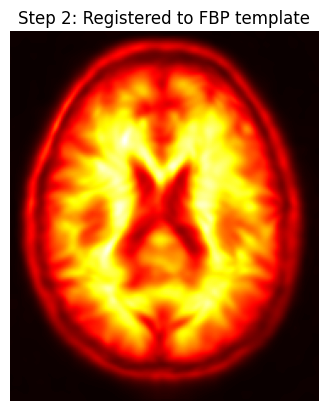

Registered shape: (182, 218, 182)


In [13]:
template_ants = ants.from_numpy(template, origin=mni.origin,
                                 spacing=mni.spacing, direction=mni.direction)
moving = ants.from_numpy(smoothed, spacing=tuple(float(s) for s in vox))

print("Registering to FBP template (SyN) — this takes ~1–2 min...")
reg        = ants.registration(fixed=template_ants, moving=moving, type_of_transform="SyN")
registered = reg["warpedmovout"].numpy().astype(np.float32)

z = registered.shape[2] // 2
plt.imshow(np.rot90(registered[:, :, z]), cmap="hot"); plt.title("Step 2: Registered to FBP template"); plt.axis("off"); plt.show()
print(f"Registered shape: {registered.shape}")

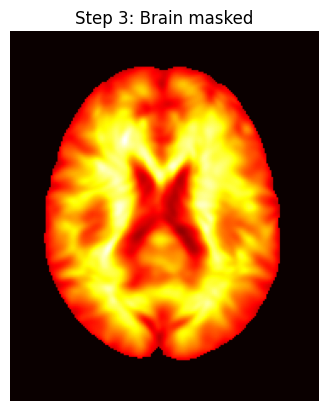

Non-zero voxels after masking: 1840910


In [14]:
masked = registered * mask.astype(np.float32)

z = masked.shape[2] // 2
plt.imshow(np.rot90(masked[:, :, z]), cmap="hot"); plt.title("Step 3: Brain masked"); plt.axis("off"); plt.show()
print(f"Non-zero voxels after masking: {int((masked > 0).sum())}")

Cerebellar mean uptake: 0.0130


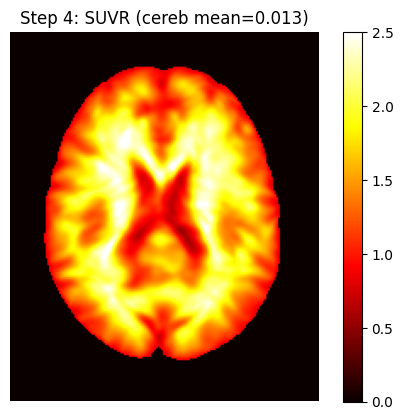

SUVR — min=0.000  max=2.883  mean=1.407


In [17]:
cereb_mean = masked[cereb_mask].mean()
print(f"Cerebellar mean uptake: {cereb_mean:.4f}")

suvr = (masked / cereb_mean).astype(np.float32)

z = suvr.shape[2] // 2
plt.imshow(np.rot90(suvr[:, :, z]), cmap="hot", vmin=0, vmax=2.5)
plt.title(f"Step 4: SUVR (cereb mean={cereb_mean:.3f})"); plt.axis("off"); plt.colorbar(); plt.show()
print(f"SUVR — min={suvr.min():.3f}  max={suvr.max():.3f}  mean={suvr[mask].mean():.3f}")